In [5]:
from nilearn import image, plotting
from nilearn.datasets import fetch_language_localizer_demo_dataset
from nilearn.glm.first_level import FirstLevelModel,make_first_level_design_matrix
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from nilearn.plotting import plot_design_matrix
from numpy import array
from glob import glob
import os
from nilearn.datasets import fetch_icbm152_brain_gm_mask
from nilearn.image import resample_to_img
from os import mkdir, path, getcwd
import nibabel as nib

In [6]:
subjects = ['12','23']

sessions = ['1', '2', '3', '4','5','6']

data_dir = 'H:\\metaphor\\Pro_proc_data\\'

out_dir = 'H:\\metaphor\\LSS\\data\\'

suffix = 'space-MNI152NLin6Asym_res-2_desc-preproc_bold'

events_dir = 'H:\\metaphor\\events\\'


In [7]:
def lss_transformer(df, row_number):
    """Label one trial for one LSS model.

    Parameters
    ----------
    df : pandas.DataFrame
        BIDS-compliant events file information.
    row_number : int
        Row number in the DataFrame.
        This indexes the trial that will be isolated.

    Returns
    -------
    df : pandas.DataFrame
        Update events information, with the select trial's trial type isolated.
    trial_name : str
        Name of the isolated trial's trial type.
    """
    df = df.copy()

    # Determine which number trial it is *within the condition*
    trial_condition = df.loc[row_number, "trial_type"]
    #trial_type_series = df["trial_type"]
    #trial_type_series = trial_type_series.loc[
    #    trial_type_series == trial_condition
    #]
    #trial_type_list = trial_type_series.index.tolist()
    #trial_number = trial_type_list.index(row_number)
    # 選擇第row_number的pic_num
    pic_num = df.loc[row_number, "pic_num"]
    
    # We use a unique delimiter here (``__``) that shouldn't be in the
    # original condition names.
    # Technically, all you need is for the requested trial to have a unique
    # 'trial_type' *within* the dataframe, rather than across models.
    # However, we may want to have meaningful 'trial_type's (e.g., 'Left_001')
    # across models, so that you could track individual trials across models.
    trial_name = f"{trial_condition}__{pic_num}"
    df.loc[row_number, "trial_type"] = trial_name
    return df, trial_name

In [8]:
for i, sub in enumerate(subjects):
    for j, ses in enumerate(sessions):
        if not os.path.exists(f'{out_dir}sub-{sub}\\run-{ses}'):
            os.makedirs(f'{out_dir}sub-{sub}\\run-{ses}')
        
        fmri_img = f'{data_dir}sub-{sub}\\run{ses}\\sub-{sub}_task-yy_run-{ses}_{suffix}.nii'
        confounds = pd.read_csv(f'{data_dir}sub-{sub}\\multi_reg\\sub-{sub}_task-yy_run-{ses}_desc-confounds_timeseries.tsv', delimiter='\t')
        events = pd.read_table(f'{events_dir}sub-{sub}\\sub-{sub}_run-{ses}_events.tsv')
        
        # Selecting columns of interest 
        
        confound_glm = confounds[['white_matter','global_signal','framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']].replace(np.nan, 0)
        #icbm_mask = fetch_icbm152_2009()
        icbm_mask = fetch_icbm152_brain_gm_mask()
        mask = resample_to_img(icbm_mask, fmri_img,
                                          interpolation='nearest')
        #mask = resample_to_img(mask, fmri_img)
        lss_glm = FirstLevelModel(t_r=2, noise_model='ar1', drift_model='cosine', high_pass=0.008, hrf_model='glover',mask_img=mask)
        
        # Loop through the trials of interest and transform the DataFrame for LSS
        #lss_beta_maps = {cond: [] for cond in events_df["trial_type"].unique()}
        lss_design_matrices = []

        for i_trial in range(events.shape[0]):
            lss_events_df, trial_condition = lss_transformer(events, i_trial)

            # Compute and collect beta maps
            #lss_glm = FirstLevelModel(**glm_parameters)
            lss_glm.fit(fmri_img, lss_events_df, confounds=confound_glm)

            # We will save the design matrices across trials to show them later
            lss_design_matrices.append(lss_glm.design_matrices_[0])

            map = lss_glm.compute_contrast(
                trial_condition,
                output_type="z_score",   
            )

            # Drop the trial number from the condition name to get the original name
            #condition_name = trial_condition.split("__")[0]
            #lss_beta_maps[condition_name].append(beta_map)
            nib.save(map, f'{out_dir}sub-{sub}\\run-{ses}\\{trial_condition}_z_map.nii')


C:\Users\dell\anaconda3\envs\nilearn\lib\site-packages\nilearn\glm\first_level\experimental_paradigm.py:166: UserWarning: The following unexpected columns in events data will be ignored: run, pic_num, subject
  warnings.warn(
C:\Users\dell\anaconda3\envs\nilearn\lib\site-packages\nilearn\glm\first_level\first_level.py:76: UserWarning: Mean values of 0 observed.The data have probably been centered.Scaling might not work as expected
  warn(
C:\Users\dell\anaconda3\envs\nilearn\lib\site-packages\nilearn\glm\first_level\experimental_paradigm.py:166: UserWarning: The following unexpected columns in events data will be ignored: run, pic_num, subject
  warnings.warn(
C:\Users\dell\anaconda3\envs\nilearn\lib\site-packages\nilearn\glm\first_level\first_level.py:76: UserWarning: Mean values of 0 observed.The data have probably been centered.Scaling might not work as expected
  warn(
C:\Users\dell\anaconda3\envs\nilearn\lib\site-packages\nilearn\glm\first_level\experimental_paradigm.py:166: UserW

C:\Users\dell\AppData\Local\Temp\ipykernel_24136\2539721802.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


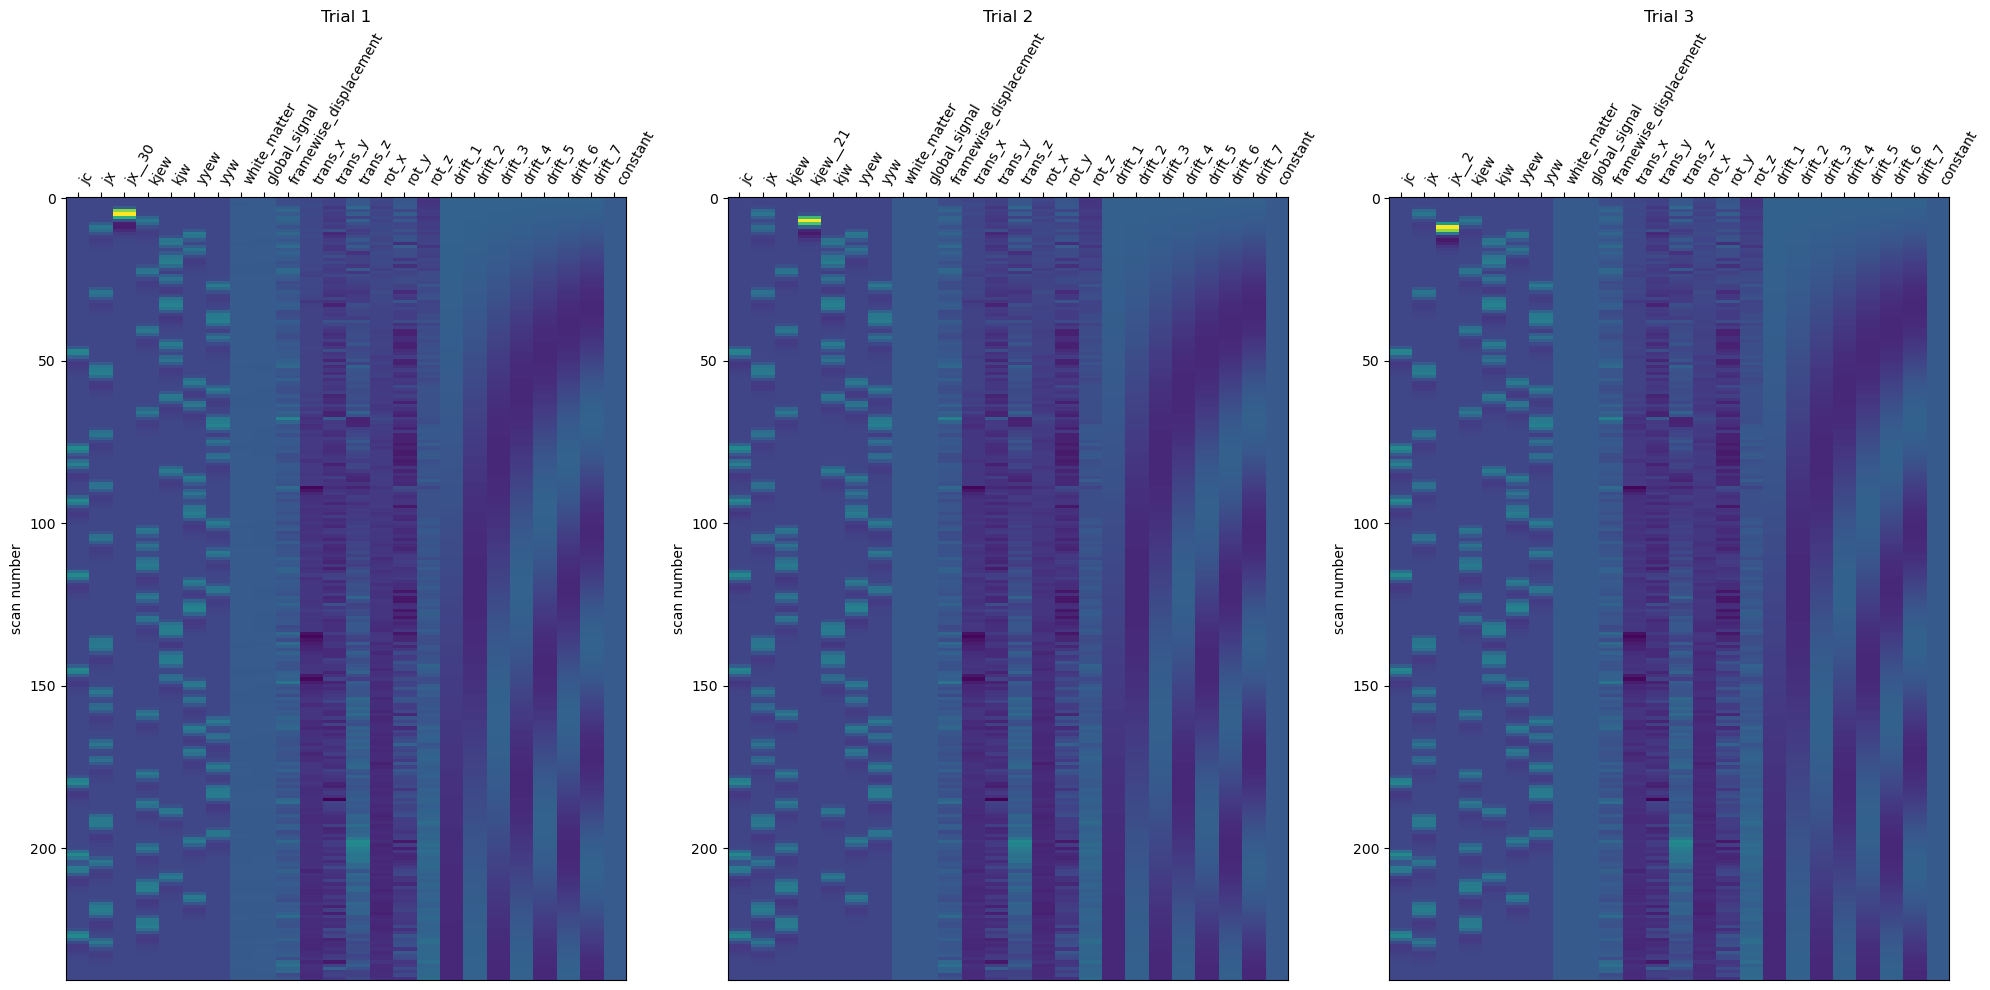

In [9]:
fig, axes = plt.subplots(ncols=3, figsize=(20, 10))
for i_trial in range(3):
    plotting.plot_design_matrix(
        lss_design_matrices[i_trial],
        ax=axes[i_trial],
    )
    axes[i_trial].set_title(f"Trial {i_trial + 1}")

fig.show()